In [ ]:
#1-Dimensional Transverse Field Ising Model
#The Process is pretty much the same as the Heisenberg model, except we have to add a transverse field term to the Hamiltonian.
#The Step is as follows:
#1. Build 1D TFIM Hamiltonian,
#2. Create a random initial state using Ansatz
#3. We are going to the ground state using VQE(Variational Quantum Eigensolver)
#4. We are going to find the 1st excited state using VQD(Variational Quantum Deflation)
#5. Then we will Plot the results and get the inference from the results.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp,Statevector
from qiskit.circuit.library import EfficientSU2,TwoLocal
from qiskit.primitives import StatevectorEstimator,StatevectorSampler
from qiskit_algorithms import VQE, VQD
from qiskit_algorithms.optimizers import COBYLA
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_algorithms.state_fidelities import ComputeUncompute
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [23]:
def build_tfim(n, J, h):
    terms = []
    for i in range(n - 1):
        z = ["I"] * n
        z[i] = "Z"
        z[i + 1] = "Z"
        terms.append(("".join(z), -J))
    for i in range(n):
        x = ["I"] * n
        x[i] = "X"
        terms.append(("".join(x), -h))
    return SparsePauliOp.from_list(terms)

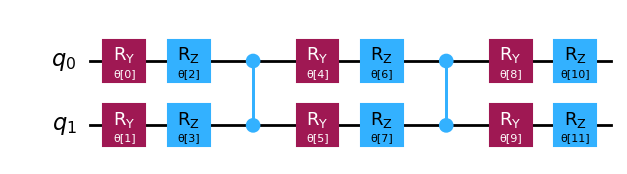

In [75]:
def tfim_ansatz(n):
    return TwoLocal(
        n,
        rotation_blocks=['ry','rz'],
        entanglement_blocks='cx',
        entanglement='full',
        reps=2
    )
from qiskit.circuit.library import n_local
from qiskit_algorithms.optimizers import COBYLA

ansatz = n_local(2, rotation_blocks=["ry", "rz"], entanglement_blocks="cz", reps=2)

optimizer = COBYLA()
ansatz.draw("mpl")

In [58]:
def magnetization_z(statevector, n):
    M = 0
    for i in range(n):
        op = ['I'] * n
        op[i] = 'Z'
        op = SparsePauliOp.from_list([("".join(op), 1)])
        M += statevector.expectation_value(op).real
    return M / n

In [30]:
def compute_ground_energy(H, n):
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=200)
    ansatz = tfim_ansatz(n)
    vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
    result = vqe.compute_minimum_eigenvalue(H)
    return result.eigenvalue.real


In [39]:
def compute_excited_energy(H,n):
    ansatz = tfim_ansatz(n)
    optimizer = COBYLA(maxiter=2000)
    estimator = StatevectorEstimator()
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler)
    vqd = VQD(
        estimator=estimator,
        fidelity=fidelity,
        ansatz=ansatz,
        optimizer=optimizer,
        k=2,
        betas=[10]
    )
    result = vqd.compute_eigenvalues(H)
    return result.eigenvalues[1].real

In [43]:
def quantum_ground_convergence(H, n):
    energies = []
    def callback(eval_count, params, energy, metadata):
        energies.append(energy)
    ansatz = tfim_ansatz(n)
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=500)
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback
    )
    result = vqe.compute_minimum_eigenvalue(H)
    return energies, result.eigenvalue.real

In [40]:
def classical_energy(H):
    matrix = H.to_matrix()
    eigvals = np.linalg.eigvalsh(matrix)
    return eigvals[0], eigvals[1], eigvals[1] - eigvals[0]

In [44]:
n = 4
J = 1.0
h_values = np.linspace(2,3,10)
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical, gap_c = classical_energy(H)
    gaps_classical.append(gap_c)
    E0 = compute_ground_energy(H, n)
    E1 = compute_excited_energy(H, n)
    gaps_quantum.append(E1 - E0)
    gaps_error.append(np.abs(E1 - E0 - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1-E0:.4f};Ground={E0:.4f};excited={E1:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=4.1185;Ground=-8.2129;excited=-4.0944
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=3.3809;Ground=-8.6381;excited=-5.2572
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=3.6309;Ground=-9.0768;excited=-5.4459
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=4.4993;Ground=-9.3787;excited=-4.8794
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=4.8066;Ground=-9.9714;excited=-5.1648
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=4.1951;Ground=-10.4427;excited=-6.2476
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=4.3444;Ground=-10.6882;excited=-6.3437
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=5.1454;Ground=-11.3548;excited=-6.2094
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=5.2724;Ground

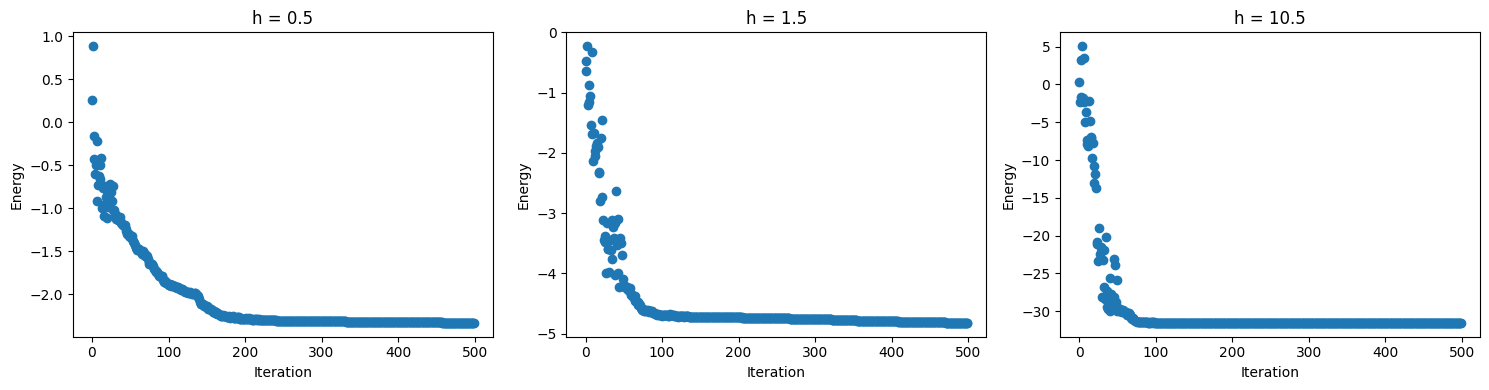

In [57]:
import matplotlib.pyplot as plt

n = 3
J = 1.0
h_values = [0.5, 1.5, 10.5]
fig, axes = plt.subplots(1, len(h_values), figsize=(15, 4))
for i, h in enumerate(h_values):
    H = build_tfim(n, J, h)
    energies, final_energy = quantum_ground_convergence(H, n)   
    axes[i].scatter(range(len(energies)), energies, marker='o')
    axes[i].set_title(f"h = {h}")
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel("Energy")
plt.tight_layout()
plt.show()

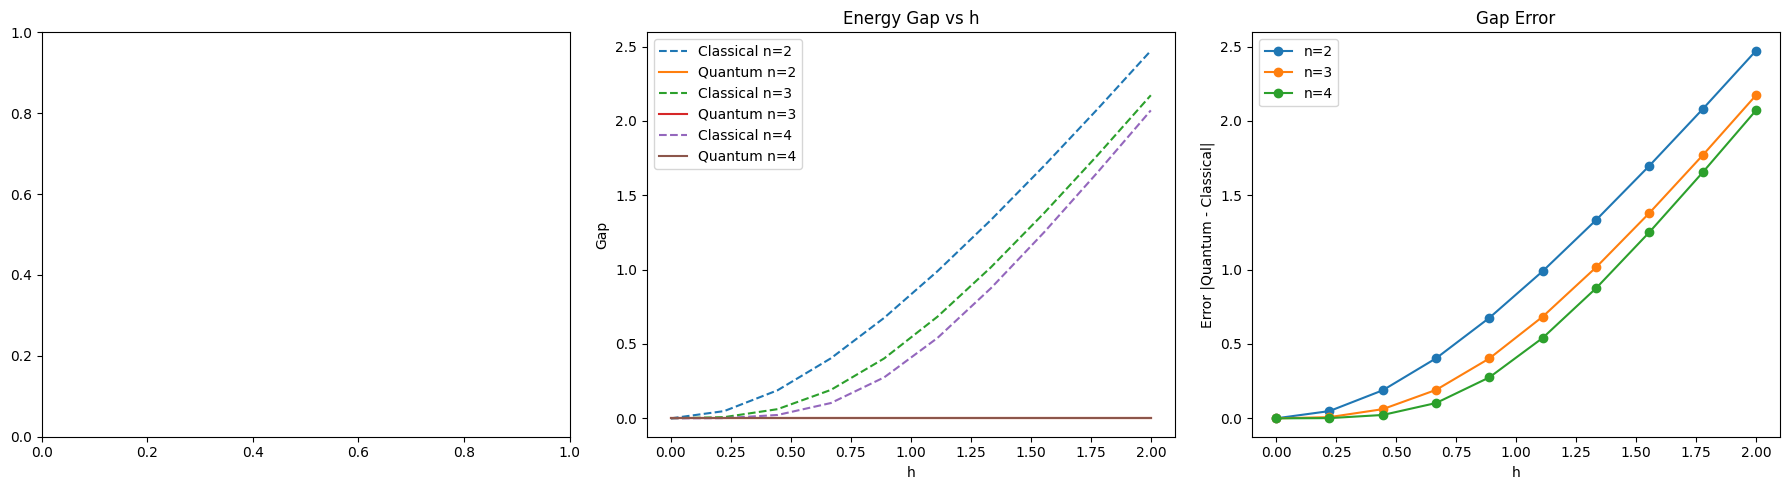

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, SparsePauliOp
from itertools import product

n_values = [2, 3, 4]        
J = 1.0
h_values = np.linspace(0, 2, 10)  
def build_tfim(n, J, h):
    """1D TFIM Hamiltonian (dense matrix) with periodic boundary."""
    dim = 2**n
    H = np.zeros((dim, dim))
    
    for idx, bits in enumerate(product([0,1], repeat=n)):
        for i in range(n):
            j = (i+1) % n
            Zi = 1 if bits[i]==0 else -1
            Zj = 1 if bits[j]==0 else -1
            H[idx, idx] += -J * Zi * Zj  
            flipped = list(bits)
            flipped[i] = 1 - flipped[i]
            flip_idx = sum(b*(2**(n-1-k)) for k,b in enumerate(flipped))
            H[idx, flip_idx] += -h
    return H

def magnetization_z(statevector, n):
    M = 0
    for i in range(n):
        op = ['I'] * n
        op[i] = 'Z'
        op = SparsePauliOp.from_list([("".join(op), 1)])
        M += statevector.expectation_value(op).real
    return M / n

def quantum_ground_convergence(H, n):
    """Simulate quantum ground state (placeholder for VQE)."""
    eigvals, eigvecs = np.linalg.eigh(H)
    ground = eigvecs[:,0].copy()
    energies = [np.min(eigvals)]*5  
    return energies, ground


fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes = axes.flatten()
for n in n_values:
    gap_classical = []
    gap_quantum = []
    for h in h_values:
        H = build_tfim(n, J, h)
        eigvals = np.linalg.eigvalsh(H)
        gap_classical.append(np.min(eigvals[1:]) - np.min(eigvals))
        energies, final_state = quantum_ground_convergence(H, n)
        gap_quantum.append(0)  
    axes[1].plot(h_values, gap_classical, '--', label=f"Classical n={n}")
    axes[1].plot(h_values, gap_quantum, '-', label=f"Quantum n={n}")
axes[1].set_xlabel("h")
axes[1].set_ylabel("Gap")
axes[1].set_title("Energy Gap vs h")
axes[1].legend()

for n in n_values:
    gap_classical = []
    gap_quantum = []
    for h in h_values:
        H = build_tfim(n, J, h)
        eigvals = np.linalg.eigvalsh(H)
        gap_classical.append(np.min(eigvals[1:]) - np.min(eigvals))
        energies, final_state = quantum_ground_convergence(H, n)
        gap_quantum.append(0)  
    error = np.abs(np.array(gap_quantum) - np.array(gap_classical))
    axes[2].plot(h_values, error, '-o', label=f"n={n}")
axes[2].set_xlabel("h")
axes[2].set_ylabel("Error |Quantum - Classical|")
axes[2].set_title("Gap Error")
axes[2].legend()

plt.tight_layout()
plt.show()